# Extracting ACS MIR spectra from the IKI binary files

In this notebook, we show an example of how to extract ACS MIR solar occultation transmission spectra from the Level 2 calibrated data produced at IKI.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import acs

### 1. Inputs

In [55]:
data_path = "/srv/workspace/data/tgo/acs/mir/iki/level_2/Pos06/110km_new_wn/"  #Path to the directory where the level 2 data is stored
filename = "MIR_2A_ORB014440_N2_E_P1_06_F_v7.4_090.DAT"          #Name of the FITS file

order = 237                 #Diffraction order to extract from the data
irows = [8,9,10,11,12,13]   #Index of the rows (above the slit edge) we want to extract

### 2. Extracting the data

In [56]:
help(acs.mir.iki.files.extract_order)

Help on function extract_order in module acs.mir.iki.files:

extract_order(filename, ordersel, irows, iki_geometry_dir='/srv/workspace/data/tgo/acs/mir/iki/geometry/')
    FUNCTION NAME : extract_order()
    
    DESCRIPTION : Function to extract a set of detector rows within a selected diffraction order 
                   from the IKI binary files
    
    INPUTS : 
    
        filename :: Name of the file
        ordersel :: Diffraction order
        irows(nrows) :: Index of row above the slit edge
        geomdir :: Base directory for the IKI geometry files
    
    OPTIONAL INPUTS: none
            
    OUTPUTS : 
    
        lat :: Latitude 
        lon :: Longitude
        Ls :: Solar longitude
        Loct :: Local time
        waven(nwave) :: Wavenumber array for the selected order (cm-1)
        trans(nwave,ngeom,nrows) :: Transmission array (3D) for the selected order
        transerr(nwave,ngeom,nrows) :: Uncertainty in transmission array
        tanhe(ngeom,nrows) :: Tan

In [57]:
lat,lon,Ls,Loct,waven,trans,transerr,tanhe = acs.mir.iki.files.extract_order(data_path+filename,order,irows)

### 3. Making summary plots

#### Single row at all altitudes

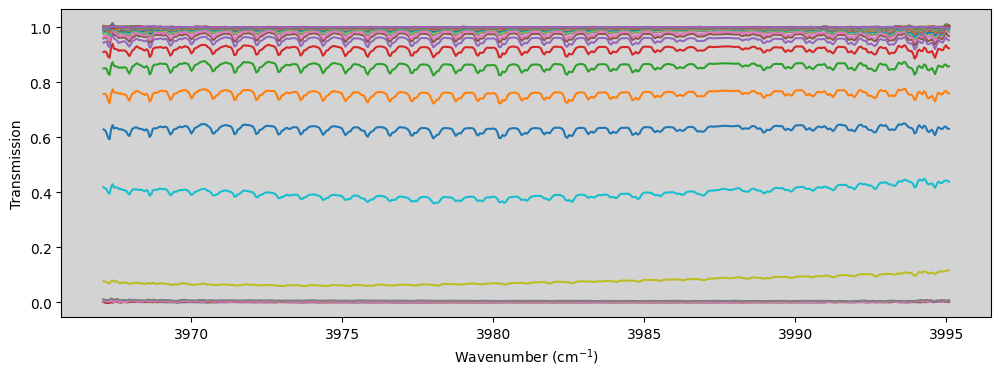

In [58]:
fig,ax1 = plt.subplots(1,1,figsize=(12,4))

irow = 0

for igeom in range(tanhe.shape[0]):
    ax1.plot(waven,trans[:,igeom,irow])

ax1.set_xlabel("Wavenumber (cm$^{-1}$)")
ax1.set_ylabel("Transmission")
ax1.set_facecolor("lightgray")

#### All rows at a single altitude

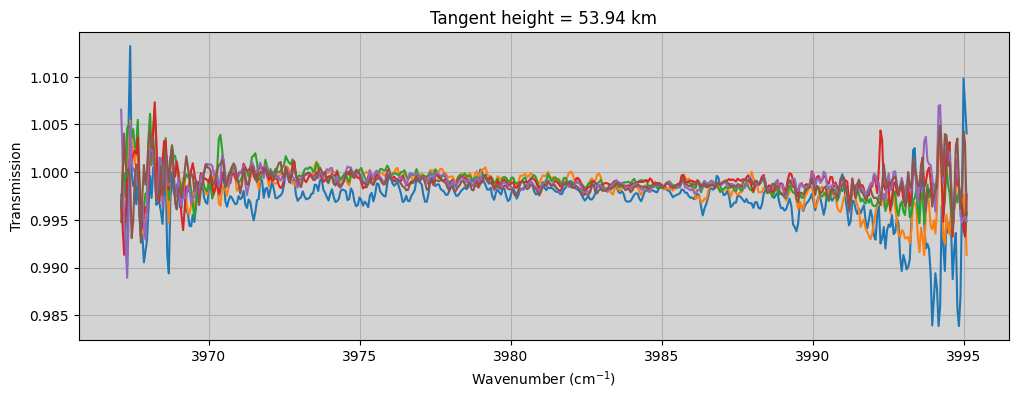

In [63]:
fig,ax1 = plt.subplots(1,1,figsize=(12,4))

igeom = 30

for irow in range(tanhe.shape[1]):
    ax1.plot(waven,trans[:,igeom,irow])
ax1.set_title(f"Tangent height = {np.round(np.mean(tanhe[igeom,:]),2)} km")

ax1.grid()
ax1.set_xlabel("Wavenumber (cm$^{-1}$)")
ax1.set_ylabel("Transmission")
ax1.set_facecolor("lightgray")